# Which inference is best, across every training mechanism?

The per-mechanism notebooks in this folder each answer a within-checkpoint question: *does any
inference cell beat what this checkpoint already does?* Each one measures its gains against a
different zero point — its own mechanism's native cell — so their numbers are **not** on a common
scale. This notebook puts every mechanism on one grid instead, at every inference cell, which is
what makes questions like this answerable:

> HCC is best under `hcc + subspace`, the baseline is best under `subspace`. How do those two
> compare with **each other**?

Rows here are `(model, mechanism)` pairs and columns are the same four readout x transform cells,
so the winner over the whole space of (mechanism, inference) combinations can be read directly.

### The caveat this notebook carries

A difference between two rows is **not** a paired inference effect. The two rows come from two
different training runs that share only the seed, the dataset and the test split, so:

- the difference **mixes the training mechanism with the readout**, and cannot be attributed to
  either one alone;
- the pairing is by seed only, not by parameter state, so report it as mean ± sample SD over
  matched seeds, never as the within-checkpoint gain of an inference rule;
- each mechanism's checkpoint was selected with **its own** native validation inference, which
  favours that mechanism's native cell over the alternatives evaluated post hoc.

The within-checkpoint gains, which do isolate the readout, stay in the per-mechanism notebooks:
[`baseline`](baseline.ipynb), [`lexmode`](lexmode.ipynb), [`hcc`](hcc.ipynb),
[`lhprojection`](lhprojection.ipynb), [`subspace_supervision`](subspace_supervision.ipynb).

### The grid of inference rules

|  | `node_score` | `subspace_norm` |
|---|---|---|
| **no transform** | rank each node by its own coordinate | rank it by the L2 norm over its ancestors+self+descendants subspace |
| **HCC projection** | `hcc_node_score` | `hcc_subspace_norm` |

Each checkpoint's own inference is one of these cells: `node_score` for H-CAST, HT-CapsNet and HRN,
`subspace_norm` for Hier-COS, and the HCC-prefixed cell for a checkpoint trained with HCC.
LH-projection and subspace supervision are Hier-COS-only by construction, so those two mechanisms
contribute a single model row each.

## Experimental cautions

1. H-CAST/HT-CapsNet/HRN coordinates were not trained as Hier-COS coordinates; identity-frame decoding is a post-hoc assumption.
2. The available best checkpoints were selected using each model's native validation inference. This can favor native inference.
3. Top-down and independent rows must use their corresponding best checkpoints. This notebook preserves that rule (`MATCHED_CHECKPOINT`).
4. Unequal seed coverage must be reported. A one-seed sign is suggestive, not robust evidence.
5. Treat this test-set analysis as a pre-specified ablation. Do not tune normalization or score variants repeatedly on test data.

In [1]:
import sys
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / 'evaluation').is_dir() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / 'evaluation').is_dir(), 'Run this notebook from inside the repository.'
if str(REPO_ROOT / 'notebooks' / 'utils') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'notebooks' / 'utils'))

import posthoc_inference_utils as posthoc

# ---- what to compare -----------------------------------------------------
# Any subset of posthoc.FAMILY_ORDER. Every listed mechanism becomes one row per
# model it supports; a mechanism with no evaluated run is reported and skipped.
EXPERIMENT_FAMILIES = list(posthoc.FAMILY_ORDER)
DATASETS = posthoc.DATASETS
# The anchor every row is measured against in the anchored-gain section below.
# 'native' uses the anchor mechanism's own inference; pass a cell name instead
# (e.g. 'subspace_norm') to anchor on one specific readout.
ANCHOR_FAMILY = 'baseline'
ANCHOR_CELL = 'native'

RUN_EVALUATION = False              # True runs the evaluator for any missing run
OVERWRITE = False
DEVICE = None
INFERENCE_MODE = 'all'
SUBSPACE_SCORE_SPACE = 'probability'

# ---- figure settings -----------------------------------------------------
posthoc.THESIS_STYLE = True
posthoc.TEXT_WIDTH_IN = 6.3
SAVE_PLOTS = True
PLOT_OUTPUT_DIR = posthoc.OUTPUTS_ROOT / 'analysis' / 'inference_analysis' / 'all_mechanics'

for family in EXPERIMENT_FAMILIES:
    print(f'{family:22s} {posthoc.FAMILY_DESCRIPTIONS[family]}')
print('\nFigures ->', PLOT_OUTPUT_DIR if SAVE_PLOTS else 'not saved')

baseline               plain hierarchical training, no gradient-space or output-space constraint
lexmode                lexicographic gradient projection, coarse-first
hcc                    Hierarchical Constraint Cascade in the output space during training
lhprojection           LH-DNN backward-only projection at the branch points (Hier-COS only)
subspace_supervision   direct supervision of the taxonomy-subspace norm (Hier-COS only)

Figures -> /scratch/g.saggini1/outputs/analysis/inference_analysis/all_mechanics


/home/g.saggini1/lexicographic_deep_learning_detailed_study/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# One row per completed run, for every mechanism. `evaluated` counts the runs
# that already carry a post-hoc result file; the rest need the next cell.
run_table = posthoc.discover_runs(EXPERIMENT_FAMILIES, datasets=DATASETS)
coverage = posthoc.coverage_table(run_table)
display(coverage)

pending = coverage[coverage['evaluated'] < coverage['runs']]
if not pending.empty:
    print('Not evaluated yet — these rows are missing from every table below:')
    display(pending)
    print('Set RUN_EVALUATION=True in the setup cell, or run the per-mechanism '
          'notebook for that family first.')

[missing] lexmode/cifar100/htcapsnet: no completed run under /scratch/g.saggini1/outputs/ht_capsnet_cifar100_lex_coarse_first
[missing] lexmode/cub200/htcapsnet: no completed run under /scratch/g.saggini1/outputs/ht_capsnet_cub200_lex_coarse_first
[missing] lexmode/aircraft/htcapsnet: no completed run under /scratch/g.saggini1/outputs/ht_capsnet_aircraft_lex_coarse_first
[missing] hcc/cifar100/htcapsnet: no completed run under /scratch/g.saggini1/outputs/capsnet_cifar100_hcc
[missing] hcc/cifar100/hrn: no completed run under /scratch/g.saggini1/outputs/hrn_cifar100_level_marginal_hcc
[missing] hcc/cub200/htcapsnet: no completed run under /scratch/g.saggini1/outputs/capsnet_cub200_hcc
[missing] hcc/cub200/hrn: no completed run under /scratch/g.saggini1/outputs/hrn_cub200_level_marginal_hcc
[missing] hcc/aircraft/htcapsnet: no completed run under /scratch/g.saggini1/outputs/capsnet_aircraft_hcc
[missing] hcc/aircraft/hrn: no completed run under /scratch/g.saggini1/outputs/hrn_aircraft_le

,family,dataset_slug,model,runs,evaluated
0,baseline,aircraft,hcast,3,3
1,baseline,aircraft,hiercos,3,3
2,baseline,aircraft,hrn,3,3
3,baseline,aircraft,htcapsnet,3,3
4,baseline,cifar100,hcast,3,3
5,baseline,cifar100,hiercos,3,3
6,baseline,cifar100,hrn,3,3
7,baseline,cifar100,htcapsnet,3,3
8,baseline,cub200,hcast,3,3
9,baseline,cub200,hiercos,3,3


Not evaluated yet — these rows are missing from every table below:


,family,dataset_slug,model,runs,evaluated
27,lhprojection,aircraft,hiercos,3,0
28,lhprojection,cifar100,hiercos,3,0
29,lhprojection,cub200,hiercos,3,0
30,subspace_supervision,aircraft,hiercos,3,0
31,subspace_supervision,cifar100,hiercos,3,0
32,subspace_supervision,cub200,hiercos,3,0


Set RUN_EVALUATION=True in the setup cell, or run the per-mechanism notebook for that family first.


In [3]:
# Evaluating a mechanism here writes exactly the same file the per-mechanism
# notebook writes, into the run's own directory, so the work is never duplicated.
# Run this cell from one kernel at a time.
result_files = posthoc.evaluate_runs(
    run_table,
    run_evaluation=RUN_EVALUATION,
    overwrite=OVERWRITE,
    device=DEVICE,
    inference_mode=INFERENCE_MODE,
    subspace_score_space=SUBSPACE_SCORE_SPACE,
)

Available result files: 81/99


In [4]:
# `by='model_family'` is what makes this notebook different from the others:
# every (model, mechanism) pair becomes its own row on every grid.
results_long = posthoc.add_series(posthoc.load_results(run_table), by='model_family')
if not results_long.empty:
    display(results_long.groupby(['dataset', 'model', 'family'])['inference']
            .agg(lambda values: ', '.join(sorted(set(values))))
            .reset_index().rename(columns={'inference': 'available inference cells'}))

Loaded rows: 9072


,dataset,model,family,available inference cells
0,cifar-100,hcast,baseline,"hcc_node_score, hcc_subspace_norm, node_score,..."
1,cifar-100,hcast,hcc,"hcc_node_score, hcc_subspace_norm, node_score,..."
2,cifar-100,hcast,lexmode,"hcc_node_score, hcc_subspace_norm, node_score,..."
3,cifar-100,hiercos,baseline,"hcc_node_score, hcc_subspace_norm, node_score,..."
4,cifar-100,hiercos,hcc,"hcc_node_score, hcc_subspace_norm, node_score,..."
5,cifar-100,hiercos,lexmode,"hcc_node_score, hcc_subspace_norm, node_score,..."
6,cifar-100,hrn,baseline,"hcc_node_score, hcc_subspace_norm, node_score,..."
7,cifar-100,hrn,lexmode,"hcc_node_score, hcc_subspace_norm, node_score,..."
8,cifar-100,ht_capsnet,baseline,"hcc_node_score, hcc_subspace_norm, node_score,..."
9,cub-200-2011,hcast,baseline,"hcc_node_score, hcc_subspace_norm, node_score,..."


In [5]:
# =====================  WHAT TO SHOW  =====================================
SHOW_INFERENCES = 'all'      # 'all' | 'native' | e.g. ['subspace_norm', 'hcc_subspace_norm']
SHOW_DECODERS = 'both'       # 'both' | 'independent' | 'topdown'
SHOW_DATASETS = 'all'        # 'all' | e.g. ['cifar-100']
SHOW_MODELS = 'all'          # 'all' | e.g. ['hcast', 'hiercos']
SHOW_FAMILIES = 'all'        # 'all' | e.g. ['baseline', 'hcc']
SHOW_METRICS = ('fpa', 'weighted_ap', 'tice', 'ahd')
MATCHED_CHECKPOINT = True    # repo rule: read each decoder from its own checkpoint
# ==========================================================================

view = posthoc.select(results_long, inferences=SHOW_INFERENCES, decoders=SHOW_DECODERS,
                      datasets=SHOW_DATASETS, models=SHOW_MODELS, families=SHOW_FAMILIES,
                      metrics=SHOW_METRICS, matched_checkpoint=MATCHED_CHECKPOINT)
posthoc.describe_selection(view, MATCHED_CHECKPOINT)
absolute_summary = posthoc.absolute_summary(view)

Selected 2592 rows
  inference cells : node_score, subspace_norm, hcc_node_score, hcc_subspace_norm
  decoders        : independent, topdown
  datasets        : cifar-100, cub-200-2011, fgvc-aircraft
  models          : hcast, hiercos, hrn, ht_capsnet
  mechanisms      : baseline, hcc, lexmode
  metrics         : ahd, fpa, tice, weighted_ap
  checkpoint rule : matched to decoder


## 1. The best inference, over every mechanism

`rank_cells` ranks all (mechanism, cell) combinations inside each (dataset, model) group and
`best_cells` keeps the winner. Read `margin` — the distance to the runner-up — against
`best_std`: a win smaller than the seed spread is a tie, not a result. `native_value` is the
winning row's own native readout, so the part of the win that the *readout* contributes, rather
than the mechanism, is visible on the same line.

Change `RANK_METRIC`/`RANK_DECODER` to rank on TICE, AHD or top-down decoding instead.

In [6]:
RANK_METRIC = 'fpa'          # any key of posthoc.METRIC_SPECS that is loaded
RANK_DECODER = 'independent'  # 'independent' | 'topdown'

if absolute_summary.empty:
    print('Nothing to rank for the current selection.')
else:
    print(f'Winner per (dataset, model) — {RANK_METRIC} under {RANK_DECODER} decoding:')
    display(posthoc.best_cells(absolute_summary, metric=RANK_METRIC,
                               decoder=RANK_DECODER).round(3))

    ranked = posthoc.rank_cells(absolute_summary, metric=RANK_METRIC, decoder=RANK_DECODER)
    print(f'\nFull ranking (top {min(15, len(ranked))} rows of {len(ranked)}):')
    display(ranked.head(15).round(3))

Winner per (dataset, model) — fpa under independent decoding:


,dataset,model,best_family,best_inference,best_value,best_std,native_inference,native_value,margin,runner_up,runner_up_family,seeds
0,cifar-100,hcast,hcc,hcc_subspace_norm,75.790,0.292,hcc_node_score,73.683,0.083,subspace_norm,hcc,3
1,cifar-100,hiercos,baseline,subspace_norm,77.520,0.156,subspace_norm,77.520,0.203,subspace_norm,lexmode,3
2,cifar-100,hrn,baseline,subspace_norm,75.947,0.110,node_score,71.667,1.227,hcc_subspace_norm,baseline,3
3,cifar-100,ht_capsnet,baseline,hcc_subspace_norm,27.290,18.523,node_score,26.663,0.030,subspace_norm,baseline,3
4,cub-200-2011,hcast,baseline,subspace_norm,83.017,0.150,node_score,81.268,0.092,hcc_subspace_norm,baseline,3
5,cub-200-2011,hiercos,lexmode,subspace_norm,76.453,0.733,subspace_norm,76.453,0.230,node_score,lexmode,3
6,cub-200-2011,hrn,baseline,subspace_norm,85.738,0.147,node_score,84.150,0.449,subspace_norm,lexmode,3
7,cub-200-2011,ht_capsnet,baseline,node_score,24.140,0.414,node_score,24.140,0.017,hcc_node_score,baseline,3
8,fgvc-aircraft,hcast,baseline,hcc_subspace_norm,73.727,0.788,node_score,70.727,0.060,subspace_norm,baseline,3
9,fgvc-aircraft,hiercos,baseline,subspace_norm,81.398,0.523,subspace_norm,81.398,0.130,subspace_norm,lexmode,3



Full ranking (top 15 rows of 108):


,dataset,model,family,series,inference,is_native,mean_value,std_value,seeds,rank,gap_to_best
0,cifar-100,hcast,hcc,hcast | hcc,hcc_subspace_norm,False,75.790,0.292,3,1,0.000
1,cifar-100,hcast,hcc,hcast | hcc,subspace_norm,False,75.707,0.345,3,2,-0.083
2,cifar-100,hcast,lexmode,hcast | lexmode,hcc_subspace_norm,False,75.520,0.217,3,3,-0.270
3,cifar-100,hcast,lexmode,hcast | lexmode,subspace_norm,False,75.513,0.194,3,4,-0.277
4,cifar-100,hcast,baseline,hcast | baseline,subspace_norm,False,75.343,0.046,3,5,-0.447
5,cifar-100,hcast,baseline,hcast | baseline,hcc_subspace_norm,False,75.280,0.173,3,6,-0.510
6,cifar-100,hcast,lexmode,hcast | lexmode,node_score,True,74.080,0.193,3,7,-1.710
7,cifar-100,hcast,hcc,hcast | hcc,hcc_node_score,True,73.683,0.317,3,8,-2.107
8,cifar-100,hcast,baseline,hcast | baseline,node_score,True,73.477,0.187,3,9,-2.313
9,cifar-100,hcast,lexmode,hcast | lexmode,hcc_node_score,False,72.267,0.250,3,10,-3.523


[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/all_mechanics/best_cell_fpa_independent.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/all_mechanics/best_cell_fpa_independent.png


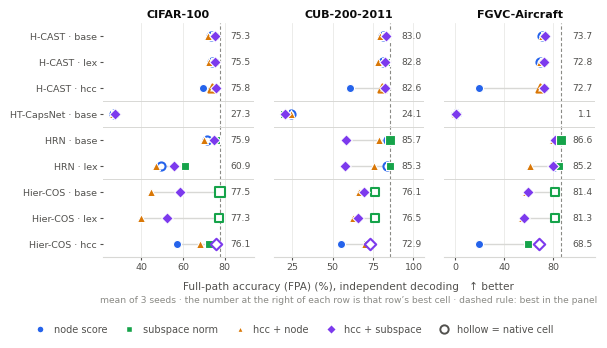


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/best_cell_fpa_independent}
  \caption{Every inference cell of every training mechanism, FPA under independent decoding, mean over 3 seeds. Each row is one (model, mechanism) pair and carries all four readout$\times$transform cells; the hollow marker is the cell that reproduces that checkpoint's own inference and the dashed rule marks the best value in the panel. Each dataset panel has its own horizontal range, because absolute levels are not comparable across datasets. Rows come from different training runs, so a difference between rows mixes the training mechanism with the inference rule and is matched by seed only, unlike the within-checkpoint gains.}
  \label{fig:posthoc-best-inference-fpa}
\end{figure}
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/all_mechanics/best_cell_tice_independent.pdf
[saved] /scratch/g.saggini1/ou

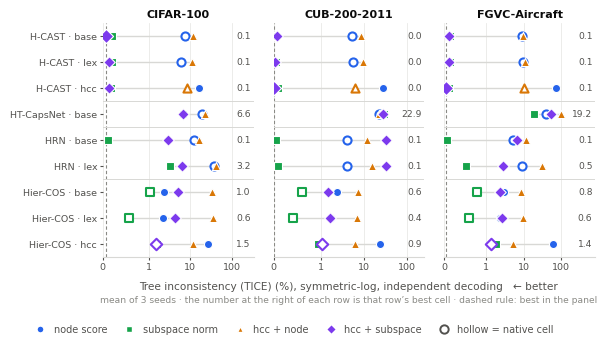


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/best_cell_tice_independent}
  \caption{Every inference cell of every training mechanism, TICE under independent decoding, mean over 3 seeds. Each row is one (model, mechanism) pair and carries all four readout$\times$transform cells; the hollow marker is the cell that reproduces that checkpoint's own inference and the dashed rule marks the best value in the panel. Each dataset panel has its own horizontal range, because absolute levels are not comparable across datasets. Rows come from different training runs, so a difference between rows mixes the training mechanism with the inference rule and is matched by seed only, unlike the within-checkpoint gains.}
  \label{fig:posthoc-best-inference-tice}
\end{figure}


In [7]:
# Every cell of every mechanism on one axis per dataset: the hollow marker is
# each row's own native cell, the dashed rule the best value in the panel.
if SAVE_PLOTS:
    PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def path(name):
    return (PLOT_OUTPUT_DIR / f'{name}.pdf') if SAVE_PLOTS else None


CHART_METRICS = ('fpa', 'tice')

if absolute_summary.empty:
    print('Nothing to plot for the current selection.')
else:
    for metric in CHART_METRICS:
        posthoc.best_inference_chart(absolute_summary, metric=metric,
                                     decoder=RANK_DECODER,
                                     save_path=path(f'best_cell_{metric}_{RANK_DECODER}'))

## 2. Where every mechanism x cell actually lands

The same table as a grid, in raw test units. Shading is normalised **inside each dataset block**,
so colour ranks the rows against each other on that dataset; the bold outline marks each row's own
native cell. This is the figure that answers "HCC under `hcc + subspace` versus baseline under
`subspace`" by reading two tiles on the same ramp — subject to the caveat at the top of this
notebook.

[note] 12 columns need 6.83 in; at width=\textwidth LaTeX scales it to 92%.
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/all_mechanics/absolute_grid_all_mechanics.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/all_mechanics/absolute_grid_all_mechanics.png


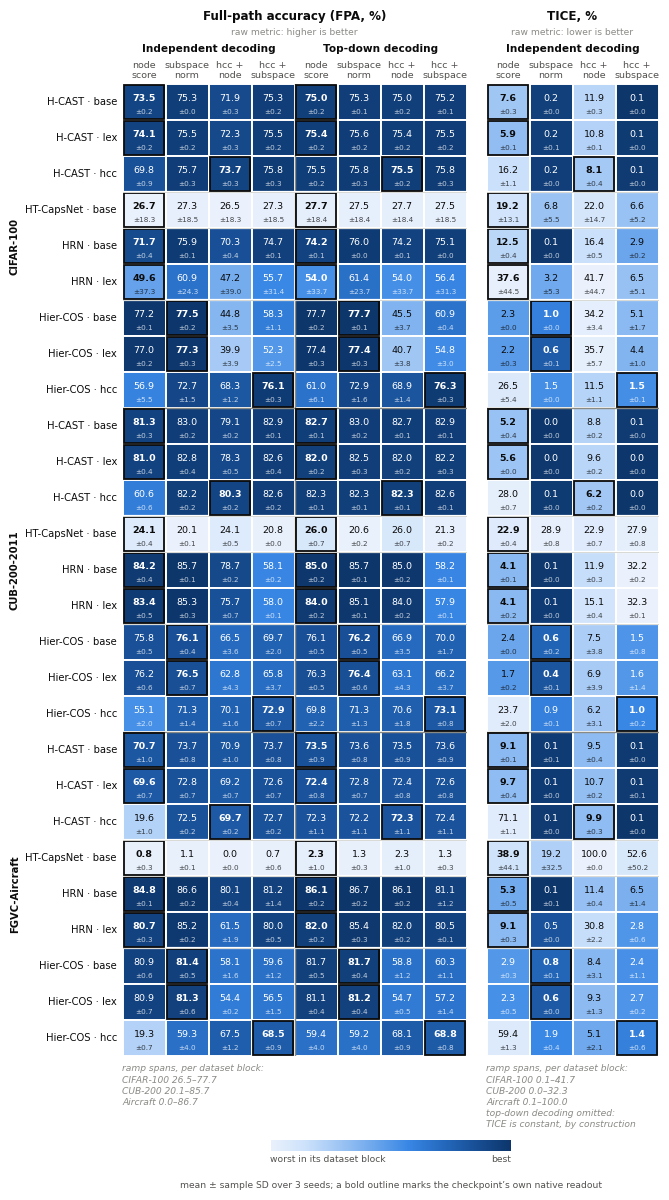


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/absolute_grid_all_mechanics}
  \caption{Absolute post-hoc test values: every readout$\times$transform cell for every row, mean $\pm$ sample standard deviation over 3 seeds, each decoder read from its own validation-selected checkpoint. Shading is normalised separately inside each dataset block, because absolute levels are not comparable across datasets, and is direction-adjusted so that darker is always better; the span of every ramp is printed under the panel and the exact value in every tile. A bold outline marks the cell that reproduces the checkpoint's own inference. Rows are (model, mechanism) pairs from different training runs, matched by seed only, so a difference between rows mixes the training mechanism with the inference rule.}
  \label{fig:posthoc-absolute-grid}
\end{figure}


In [8]:
ABS_GRID_METRICS = ('fpa', 'tice')
ABS_SHOW_SPREAD = True
ABS_SHADE_SCOPE = 'dataset'          # 'dataset' | 'row' | 'panel'

if absolute_summary.empty:
    print('Nothing to plot for the current selection.')
else:
    posthoc.absolute_grid(absolute_summary, metrics=ABS_GRID_METRICS,
                          show_spread=ABS_SHOW_SPREAD, shade_scope=ABS_SHADE_SCOPE,
                          save_path=path('absolute_grid_all_mechanics'),
                          caption_note=' Rows are (model, mechanism) pairs from different '
                                       'training runs, matched by seed only, so a difference '
                                       'between rows mixes the training mechanism with the '
                                       'inference rule.')

## 3. Everything against one anchor

The grid above is absolute. This section subtracts one chosen anchor from every row, so the whole
comparison is expressed as a signed delta: `ANCHOR_FAMILY` read at `ANCHOR_CELL` (default: the
baseline mechanism read natively) is the zero, and every other (mechanism, cell) is measured
against it, per seed and then averaged.

Positive always means the listed row is better, including for the lower-is-better TICE and AHD.
Set `ANCHOR_CELL = 'subspace_norm'` to ask instead what each mechanism adds *on top of* the readout
the baseline already benefits from — that separates "the mechanism helps" from "the readout helps".

Every number in this section carries the caveat at the top of the notebook: it is a
between-training-run difference, matched by seed only.

In [9]:
anchored = anchored_summary = pd.DataFrame()

if results_long.empty:
    print('Nothing loaded.')
else:
    anchored = posthoc.cross_family_gains(results_long, anchor_family=ANCHOR_FAMILY,
                                          anchor_cell=ANCHOR_CELL,
                                          matched_checkpoint=MATCHED_CHECKPOINT)
    anchored = posthoc.add_series(anchored, by='model_family')
    anchored = anchored[anchored['metric_family'].isin(SHOW_METRICS)
                        & anchored['dataset'].isin(set(view['dataset']))
                        & anchored['series'].isin(set(view['series']))]
    anchored_summary = posthoc.summarize_samples(
        anchored,
        ['dataset', 'model', 'family', 'series', 'decoder', 'inference', 'metric_family'],
        'gain_display', 'mean_gain', 'std_gain')
    anchor_cells = ', '.join(sorted(set(anchored['anchor_cell'])))
    print(f'Anchor: {ANCHOR_FAMILY} read with {anchor_cells}. '
          'Positive favours the listed row, for every metric.')
    print('Between-run difference, matched by seed only — not a within-checkpoint gain.')
    display(anchored_summary.round(3))

Anchor: baseline read with node_score, subspace_norm. Positive favours the listed row, for every metric.
Between-run difference, matched by seed only — not a within-checkpoint gain.


,dataset,model,family,series,decoder,inference,metric_family,mean_gain,std_gain,seeds
0,cifar-100,hcast,baseline,hcast | baseline,independent,hcc_node_score,ahd,-0.020,0.002,3
1,cifar-100,hcast,baseline,hcast | baseline,independent,hcc_node_score,fpa,-1.567,0.142,3
2,cifar-100,hcast,baseline,hcast | baseline,independent,hcc_node_score,tice,-4.240,0.050,3
3,cifar-100,hcast,baseline,hcast | baseline,independent,hcc_node_score,weighted_ap,-0.801,0.162,3
4,cifar-100,hcast,baseline,hcast | baseline,independent,hcc_subspace_norm,ahd,0.022,0.001,3
...,...,...,...,...,...,...,...,...,...,...
859,fgvc-aircraft,ht_capsnet,baseline,ht_capsnet | baseline,topdown,node_score,weighted_ap,0.000,0.000,3
860,fgvc-aircraft,ht_capsnet,baseline,ht_capsnet | baseline,topdown,subspace_norm,ahd,-0.046,0.048,3
861,fgvc-aircraft,ht_capsnet,baseline,ht_capsnet | baseline,topdown,subspace_norm,fpa,-1.000,0.982,3
862,fgvc-aircraft,ht_capsnet,baseline,ht_capsnet | baseline,topdown,subspace_norm,tice,0.000,0.000,3


[note] 12 columns need 6.75 in; at width=\textwidth LaTeX scales it to 93% (tile labels land at 6.3 pt). Show fewer metrics, or place it on a landscape page.
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/all_mechanics/anchored_grid_baseline_native.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/all_mechanics/anchored_grid_baseline_native.png


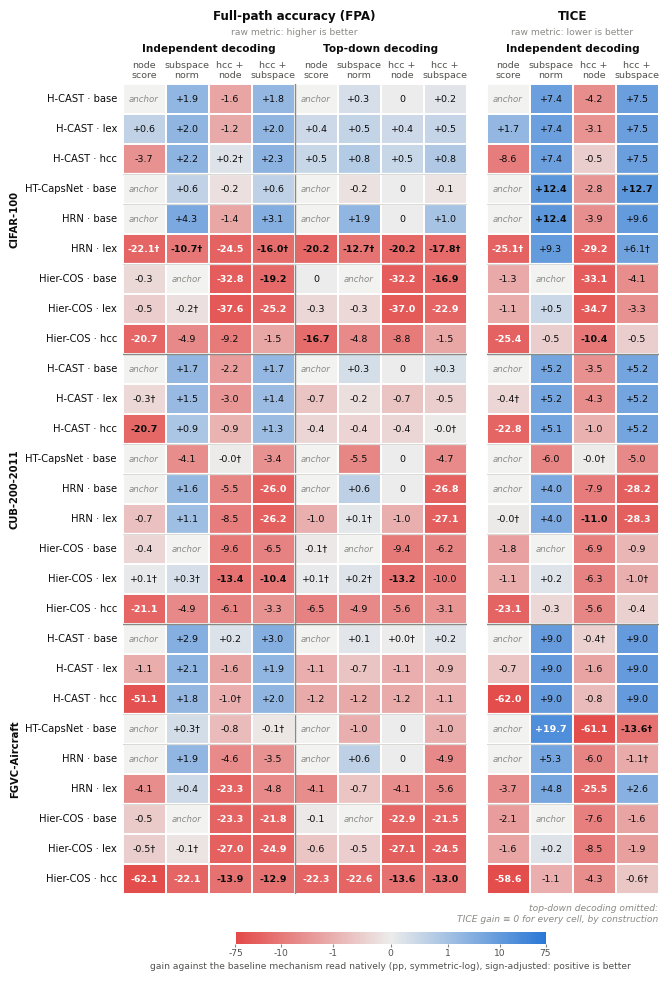


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/anchored_grid_baseline_native}
  \caption{Post-hoc inference grid. Each tile is the mean gain over 3 seeds of one readout$\times$transform cell against the baseline mechanism read natively, sign-adjusted so that positive always means better, including for the lower-is-better TICE. Colour is symmetric-log with a linear region of $\pm1$~pp, so a $1$~pp effect stays visible next to a $30$~pp collapse; read the printed numbers for exact values. \emph{anchor} marks the cell that is $0$ by definition, and $\dagger$ marks an effect whose sign is not the same for every seed. Each decoder is read from its own validation-selected checkpoint. Unlike the per-mechanism effect grids, a tile here is a difference between two training runs matched by seed only, so it mixes the training mechanism with the inference rule.}
  \label{fig:posthoc-effect-grid}
\end{

In [10]:
# The anchored deltas on the effect grid's geometry. `anchor` marks the tile that
# is zero by definition; every other tile is that row's distance from it.
if results_long.empty or anchored_summary.empty:
    print('Nothing to plot.')
else:
    anchor_map = {(row.dataset, row.series): row.anchor_cell
                  for row in anchored[anchored['is_anchor']].itertuples()}
    posthoc.effect_grid(
        anchored_summary, anchored, absolute_summary, metrics=ABS_GRID_METRICS,
        reference_map=anchor_map, reference_label='anchor',
        scale_label=(f'the {ANCHOR_FAMILY} mechanism read '
                     + ('natively' if ANCHOR_CELL == 'native' else f'with {ANCHOR_CELL}')),
        save_path=path(f'anchored_grid_{ANCHOR_FAMILY}_{ANCHOR_CELL}'),
        caption_note=' Unlike the per-mechanism effect grids, a tile here is a difference '
                     'between two training runs matched by seed only, so it mixes the '
                     'training mechanism with the inference rule.')

## 4. Accuracy against consistency, all mechanisms at once

TICE (x, log scale, lower is better) against FPA (y, higher is better) under independent decoding —
top-down decoding is consistent by construction, so its TICE is identically 0 and the trade-off
would be degenerate. Each arrow starts at a row's own native readout and ends at one alternative
cell, so **up-and-left** is a free win, **straight left** buys consistency at no accuracy cost, and
**down** is an accuracy loss. Colour is the mechanism when more than one is shown, so a cluster
that moves together is a property of the mechanism rather than of one model.

[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/all_mechanics/accuracy_consistency_all_mechanics.pdf
[saved] /scratch/g.saggini1/outputs/analysis/inference_analysis/all_mechanics/accuracy_consistency_all_mechanics.png


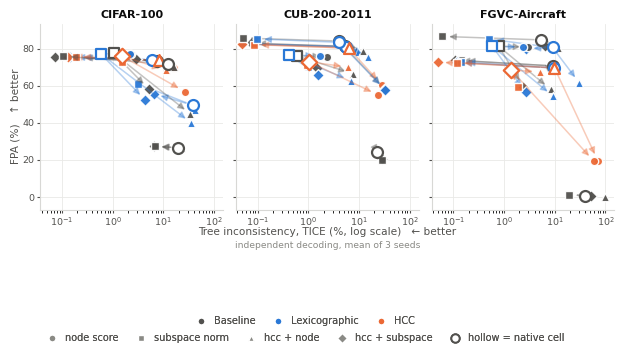


% ---- LaTeX ----------------------------------------------------
\begin{figure}[tbp]
  \centering
  \includegraphics[width=\textwidth]{figures/accuracy_consistency_all_mechanics}
  \caption{What each inference cell trades. Absolute test TICE (horizontal, log scale, lower is better) against full-path accuracy (vertical, higher is better) under independent decoding, averaged over 3 seeds. Each arrow starts at the checkpoint's own native readout (hollow marker) and ends at one alternative cell, so up-and-left is a free win, straight left buys consistency at no accuracy cost, and downward movement is an accuracy loss. Top-down decoding is omitted because it is consistent by construction (TICE $\equiv 0$); TICE values below 0.05\% are clamped to the axis floor so that they remain visible on the log scale. Rows are (model, mechanism) pairs from different training runs.}
  \label{fig:posthoc-accuracy-consistency}
\end{figure}


In [11]:
if absolute_summary.empty:
    print('Nothing to plot for the current selection.')
else:
    posthoc.accuracy_consistency_map(
        absolute_summary, save_path=path('accuracy_consistency_all_mechanics'),
        caption_note=' Rows are (model, mechanism) pairs from different training runs.')

## What this notebook does and does not establish

**It supports** statements of the form: *on CIFAR-100, the best (mechanism, inference) combination
for H-CAST is X, ahead of the runner-up by M pp against a seed spread of S*, and *mechanism A read
with cell C lands above mechanism B read with cell D*.

**It does not support** attributing that difference to the mechanism or to the readout on its own.
Only the within-checkpoint gains in the per-mechanism notebooks isolate the inference rule, because
there the two rows share one set of weights. When a row wins here, check its per-mechanism notebook
to see how much of the win the readout contributes.

Three further limits worth stating alongside any number taken from here:

1. **Checkpoint selection.** Each mechanism's checkpoint was chosen using that mechanism's own
   native validation inference, which favours its native cell.
2. **Seed coverage.** Report the seed count with the number; the tables carry it. A sign that holds
   for one seed is suggestive, not robust.
3. **Structural zeros.** `hcc_node_score` cannot change a top-down metric for a signed readout, and
   TICE is identically 0 under top-down decoding. Both are properties of the rule, and the figures
   omit those blocks rather than printing zeros.